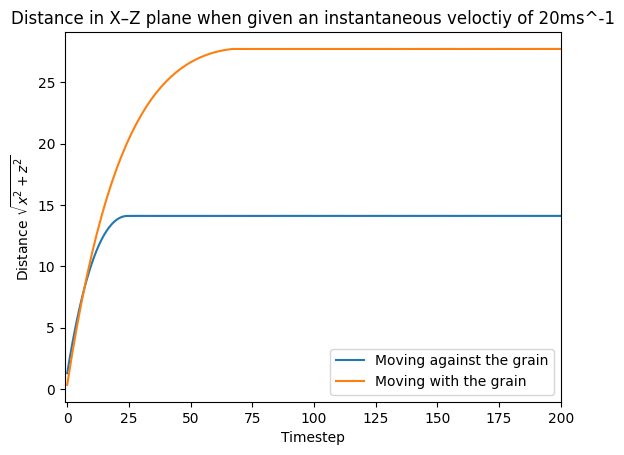

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the datasets
paths = [
    ("./cube_trajectory_1770116013072.csv", "Moving against the grain"),
    ("./cube_trajectory_1770116024717.csv", "Moving with the grain"),
]

def trim_flat_start(r, eps=1e-4):
    """
    Trim leading flat portion of r(t).
    Finds the first index where r changes by more than eps.
    """
    dr = np.abs(np.diff(r))
    idx = np.argmax(dr > eps) + 1 if np.any(dr > eps) else 0
    return r[idx:], idx

def trim_flat_end(r, eps=1e-4):
    """
        Trim trailing flat portion of r(t).
        Finds the last index where r changes by more than eps, working backwards.
        """
    dr = np.abs(np.diff(r))
    idx = len(r) - np.argmax(dr[::-1] > eps) if np.any(dr > eps) else len(r)
    return r[:idx], idx


    
plt.figure()

for path, label in paths:
    df = pd.read_csv(path)

    # distance in X–Z plane
    r_full = np.sqrt(df["posX"].to_numpy()**2 + df["posZ"].to_numpy()**2)

    # trim flat portion
    r, start_idx = trim_flat_start(r_full, eps=1e-2)

    # re-zero time
    t = np.arange(len(r))

    plt.plot(t, r, label=f"{label}")

plt.xlabel("Timestep")
plt.ylabel(r"Distance $\sqrt{x^2 + z^2}$")
plt.title("Distance in X–Z plane when given an instantaneous velocity of 20ms^-1") 
plt.xlim(-1, 200)
plt.legend()
plt.show()

